# Heart Disease Decision Support System
### Ensemble ML: Decision Tree + Random Forest + Gaussian Naive Bayes

**Dataset:** UCI Cleveland Heart Disease dataset (303 patients, 13 clinical features)
Source: https://archive.ics.uci.edu/dataset/45/heart+disease

**Goal:** Predict presence of heart disease, combine three classifiers into a soft-voting
ensemble that outputs a confidence score, and generate clinician-friendly explanations
(SHAP + decision tree rules) for each prediction.

---


## 1. Imports & Setup

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    brier_score_loss
)
import shap

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
%matplotlib inline

RANDOM_STATE = 42
TARGET_COL = "target"


## 2. Load Raw Data

Column reference:

| Column | Meaning |
|---|---|
| age | Age in years |
| sex | 1 = male, 0 = female |
| cp | Chest pain type (0-3) |
| trestbps | Resting blood pressure (mm Hg) |
| chol | Serum cholesterol (mg/dl) |
| fbs | Fasting blood sugar > 120 mg/dl |
| restecg | Resting ECG results (0-2) |
| thalach | Max heart rate achieved |
| exang | Exercise-induced angina |
| oldpeak | ST depression induced by exercise |
| slope | Slope of peak exercise ST segment |
| ca | Major vessels colored by fluoroscopy (0-4) |
| thal | Thalassemia type |
| **target** | **1 = disease present, 0 = no disease** |


In [17]:
df_raw = pd.read_csv("heart_disease_uci.csv")
df_raw.columns = [c.strip().lower() for c in df_raw.columns]
print("Shape:", df_raw.shape)
df_raw.head()


Shape: (920, 16)


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [18]:
df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 156.4+ KB


In [19]:
df_raw.describe()


,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


## 3. Data Cleaning

Steps: normalize missing placeholders, force numeric dtypes, drop duplicates,
impute missing values, fix known data-entry errors (chol == 0 is impossible),
binarize target if needed.


In [20]:
CATEGORICAL_COLS = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]
NUMERIC_COLS = ["age", "trestbps", "chol", "thalach", "oldpeak"]

df = df_raw.copy()

# Normalize missing placeholders ('?' appears in raw multi-source UCI files)
df.replace("?", np.nan, inplace=True)
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("Missing values before imputation:")
print(df.isnull().sum()[df.isnull().sum() > 0] if df.isnull().sum().sum() > 0 else "None")

# Drop duplicates
before = len(df)
df.drop_duplicates(inplace=True)
print(f"\nDropped {before - len(df)} duplicate rows.")
df=df.droplevel[df[0]]

Missing values before imputation:
sex         920
dataset     920
cp          920
trestbps     59
chol         30
fbs          90
restecg     920
thalch       55
exang        55
oldpeak      62
slope       920
ca          611
thal        920
dtype: int64

Dropped 0 duplicate rows.


In [29]:
# 1. UPSTREAM FIX: Safely cast column types BEFORE imputation
# Only coerce the explicitly numeric columns
for col in NUMERIC_COLS:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Leave categorical columns as strings and replace text placeholders with np.nan
for col in CATEGORICAL_COLS:
    if col in df.columns:
        # Replaces string-based nulls so the imputer can recognize them
        df[col] = df[col].astype(str).replace({'?': np.nan, 'nan': np.nan, 'None': np.nan})

# 2. RUN REFINED IMPUTATION
# Now that the text data is preserved, mode imputation will work normally
for col in CATEGORICAL_COLS:
    if col in df.columns and df[col].isnull().any():
        mode_value = df[col].mode(dropna=True)
        if not mode_value.empty:
            df[col] = df[col].fillna(mode_value.iloc[0])

for col in NUMERIC_COLS:
    if col in df.columns and df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

print("\nClean shape:", df.shape)
display(df.head())


Clean shape: (920, 16)


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,target
0,1,63,NaN,NaN,NaN,145.0,233.0,1,NaN,150.0,0,2.3,NaN,0,NaN,0
1,2,67,NaN,NaN,NaN,160.0,286.0,0,NaN,108.0,1,1.5,NaN,3,NaN,1
2,3,67,NaN,NaN,NaN,120.0,229.0,0,NaN,129.0,1,2.6,NaN,2,NaN,1
3,4,37,NaN,NaN,NaN,130.0,250.0,0,NaN,187.0,0,3.5,NaN,0,NaN,0
4,5,41,NaN,NaN,NaN,130.0,204.0,0,NaN,172.0,0,1.4,NaN,0,NaN,0


## 4. Exploratory Data Analysis

### 4.1 Missingness map (before imputation, for reference)

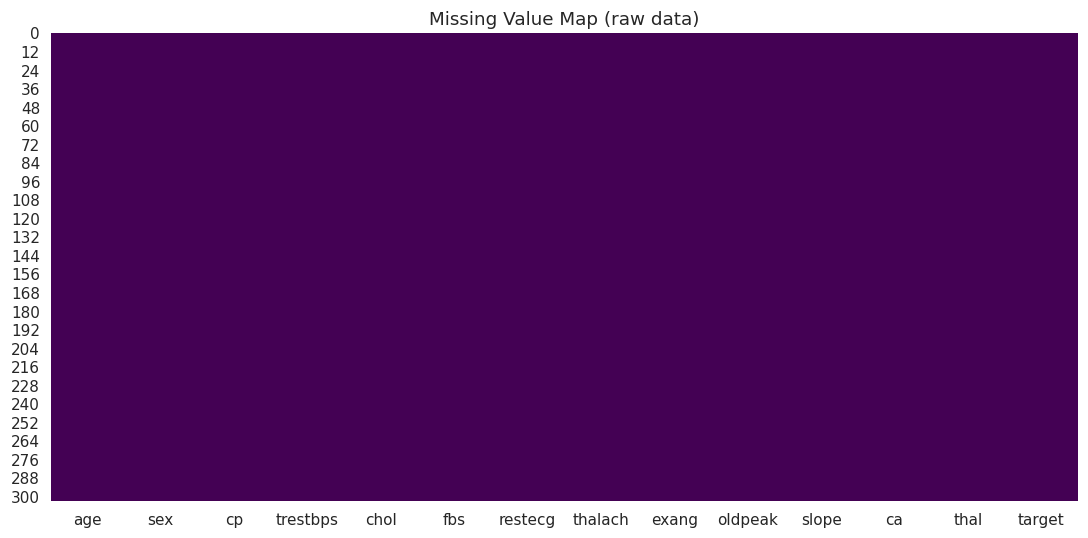

In [ ]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Value Map (raw data)")
plt.tight_layout()
plt.show()


### 4.2 Target class balance

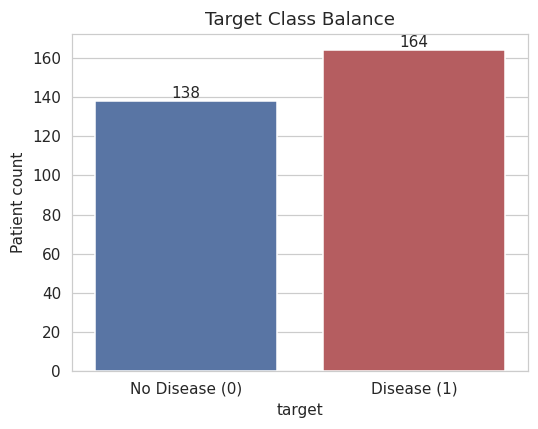

target
1    0.543
0    0.457
Name: proportion, dtype: float64


In [9]:
plt.figure(figsize=(5, 4))
ax = sns.countplot(x=TARGET_COL, hue=TARGET_COL, data=df, palette=["#4C72B0", "#C44E52"], legend=False)
ax.set_xticks([0, 1])
ax.set_xticklabels(["No Disease (0)", "Disease (1)"])
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")
plt.title("Target Class Balance")
plt.ylabel("Patient count")
plt.tight_layout()
plt.show()

print(df[TARGET_COL].value_counts(normalize=True).round(3))


### 4.3 Age distribution by diagnosis

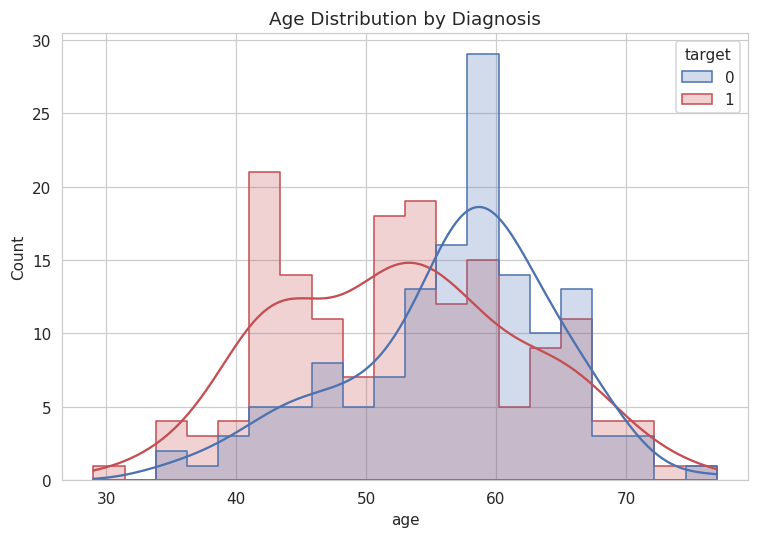

In [10]:
plt.figure(figsize=(7, 5))
sns.histplot(data=df, x="age", hue=TARGET_COL, kde=True, bins=20,
             palette=["#4C72B0", "#C44E52"], element="step")
plt.title("Age Distribution by Diagnosis")
plt.tight_layout()
plt.show()


### 4.4 Correlation heatmap

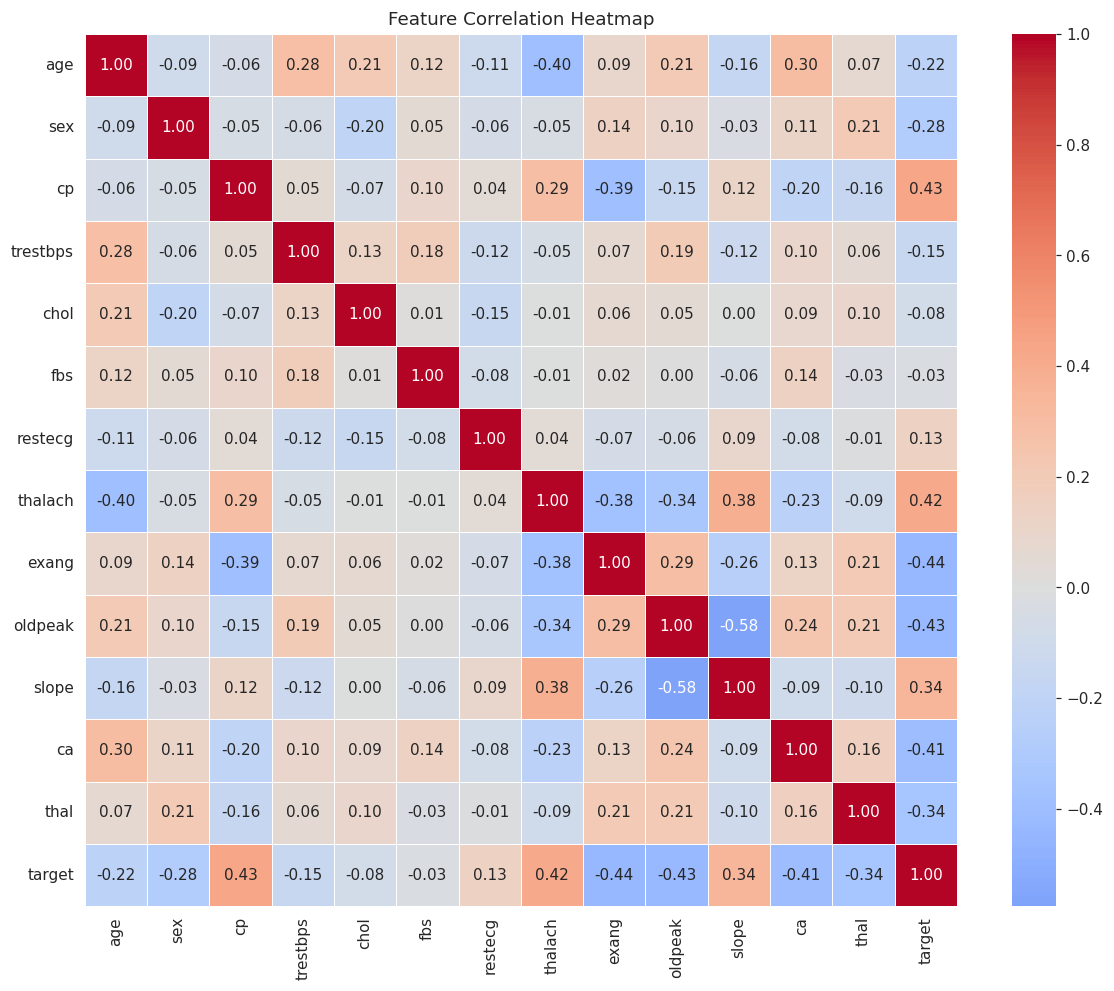

In [11]:
plt.figure(figsize=(11, 9))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()


### 4.5 Numeric features by diagnosis (outlier & separability check)

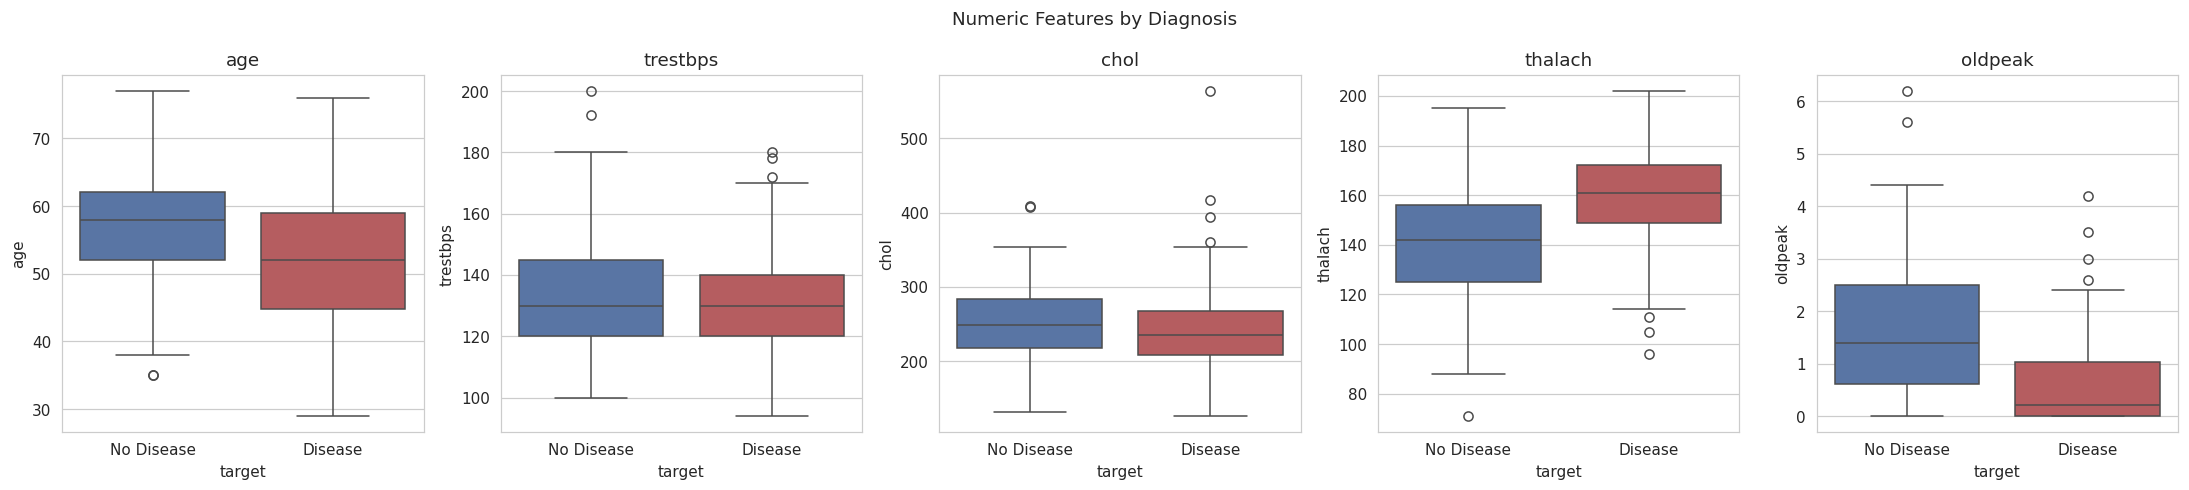

In [12]:
fig, axes = plt.subplots(1, len(NUMERIC_COLS), figsize=(4 * len(NUMERIC_COLS), 4.5))
for ax, col in zip(axes, NUMERIC_COLS):
    sns.boxplot(x=TARGET_COL, y=col, hue=TARGET_COL, data=df, ax=ax,
                palette=["#4C72B0", "#C44E52"], legend=False)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No Disease", "Disease"])
    ax.set_title(col)
plt.suptitle("Numeric Features by Diagnosis")
plt.tight_layout()
plt.show()


### 4.6 Categorical features vs target

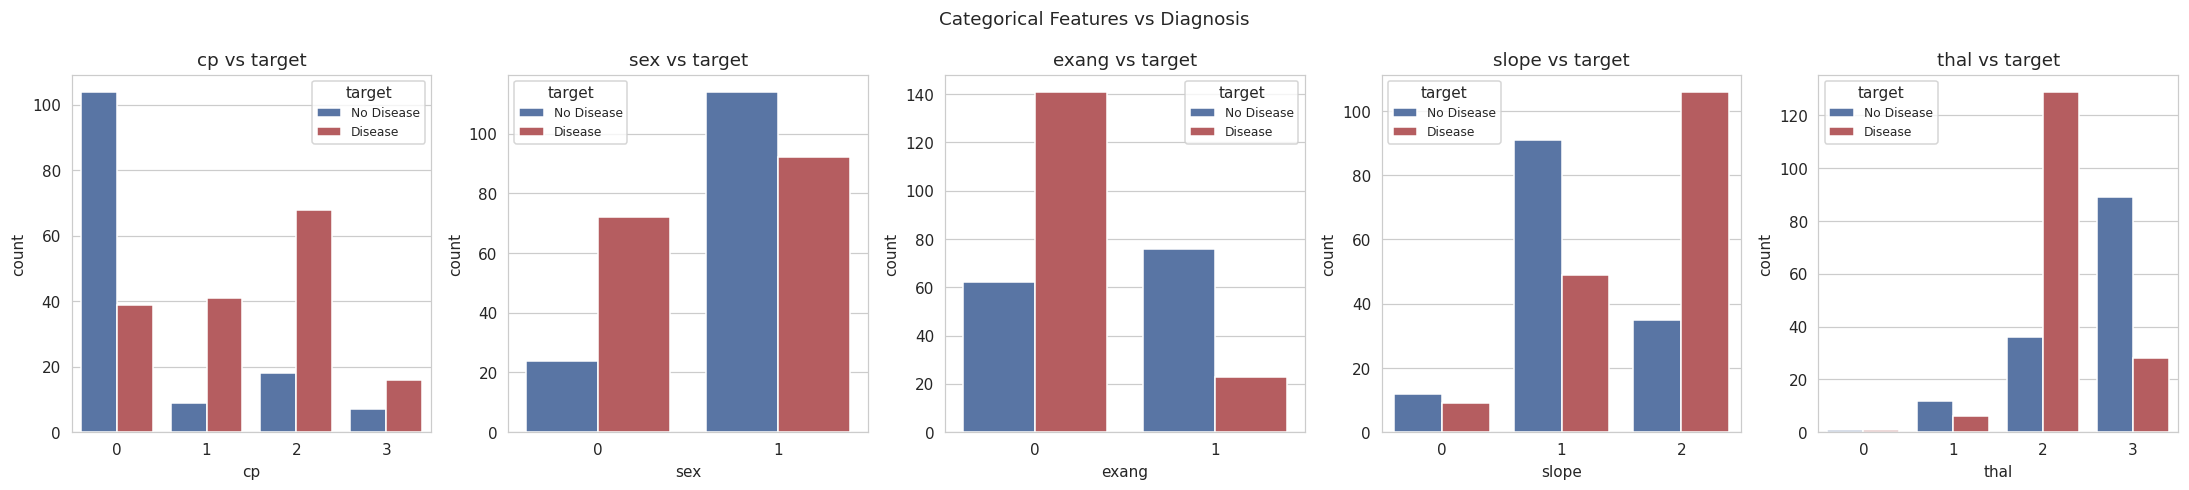

In [13]:
cat_cols_to_plot = ["cp", "sex", "exang", "slope", "thal"]
fig, axes = plt.subplots(1, len(cat_cols_to_plot), figsize=(4 * len(cat_cols_to_plot), 4.5))
for ax, col in zip(axes, cat_cols_to_plot):
    sns.countplot(x=col, hue=TARGET_COL, data=df, ax=ax, palette=["#4C72B0", "#C44E52"])
    ax.set_title(f"{col} vs target")
    ax.legend(title="target", labels=["No Disease", "Disease"], fontsize=8)
plt.suptitle("Categorical Features vs Diagnosis")
plt.tight_layout()
plt.show()


### 4.7 Pairplot of top clinically relevant features

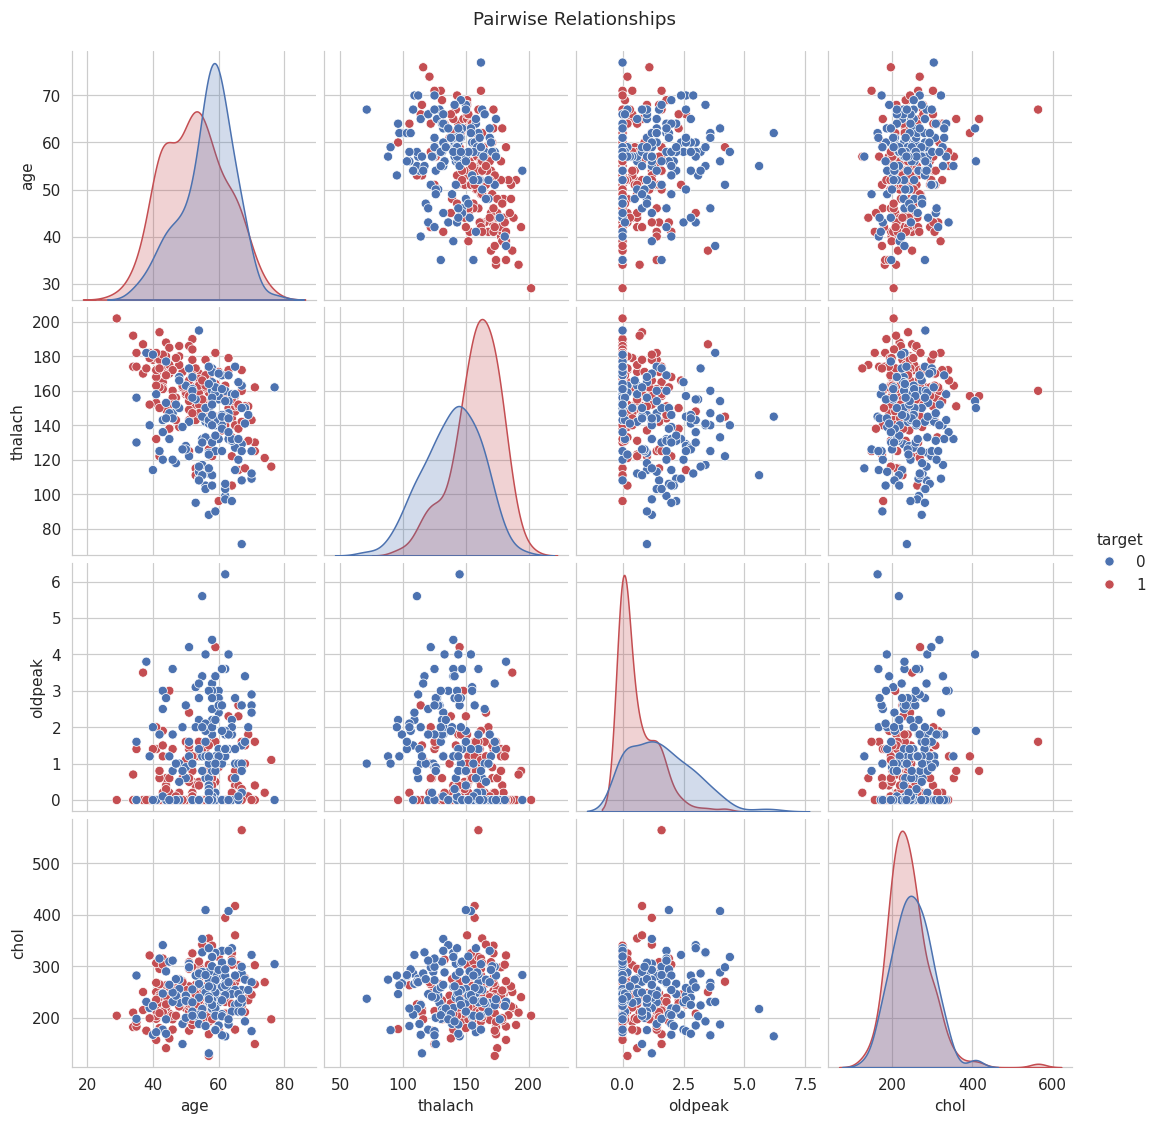

In [14]:
top_feats = ["age", "thalach", "oldpeak", "chol", TARGET_COL]
sns.pairplot(df[top_feats], hue=TARGET_COL, palette=["#4C72B0", "#C44E52"], diag_kind="kde")
plt.suptitle("Pairwise Relationships", y=1.02)
plt.show()


## 5. Train/Test Split & Scaling

- **Stratified split** (80/20) to preserve class balance in both sets.
- **StandardScaler** fit only on training data, then applied to test data (prevents leakage).


In [15]:
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("\nTrain class balance:\n", y_train.value_counts(normalize=True).round(3))
print("\nTest class balance:\n", y_test.value_counts(normalize=True).round(3))


Train shape: (241, 13)  Test shape: (61, 13)

Train class balance:
 target
1    0.544
0    0.456
Name: proportion, dtype: float64

Test class balance:
 target
1    0.541
0    0.459
Name: proportion, dtype: float64


In [16]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

feature_names = list(X.columns)
X_train_scaled.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
59,0.289062,-1.473449,-0.935691,-0.192086,1.222784,-0.405279,-1.041992,0.405122,-0.718139,-0.889676,0.964611,0.264036,-0.575142
247,1.267182,0.678680,0.062103,1.590543,0.035438,-0.405279,0.846129,-1.364273,1.392489,-0.889676,-0.638639,2.221962,-2.245133
289,0.071702,-1.473449,-0.935691,-0.192086,-0.818618,-0.405279,2.734250,-0.910582,1.392489,0.771788,-0.638639,0.264036,1.094849
288,0.289062,0.678680,-0.935691,-1.194814,1.889363,-0.405279,0.846129,-0.320784,1.392489,1.602520,-0.638639,0.264036,1.094849
64,0.397742,0.678680,1.059898,0.476400,-0.693634,2.467435,-1.041992,0.677336,-0.718139,-0.889676,0.964611,-0.714928,-0.575142


## 6. Build & Cross-Validate Models

In [17]:
dt = DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, random_state=RANDOM_STATE)
rf = RandomForestClassifier(n_estimators=300, max_depth=6, min_samples_leaf=3,
                             random_state=RANDOM_STATE, class_weight="balanced")
nb = GaussianNB()

models = {"Decision Tree": dt, "Random Forest": rf, "Gaussian Naive Bayes": nb}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print("5-Fold Stratified Cross-Validation (ROC-AUC):")
for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=skf, scoring="roc_auc")
    print(f"  {name}: mean AUC = {scores.mean():.3f} (+/- {scores.std():.3f})")


5-Fold Stratified Cross-Validation (ROC-AUC):
  Decision Tree: mean AUC = 0.818 (+/- 0.074)


  Random Forest: mean AUC = 0.897 (+/- 0.064)
  Gaussian Naive Bayes: mean AUC = 0.881 (+/- 0.061)


### 6.1 Fit all models on the full training set

In [18]:
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
print("All models trained.")


All models trained.


### 6.2 Build the soft-voting ensemble

`voting="soft"` averages predicted probabilities across the three models — this is what
gives us a genuine confidence score, not just a majority-vote label.


In [19]:
ensemble = VotingClassifier(
    estimators=[("dt", dt), ("rf", rf), ("nb", nb)],
    voting="soft"
)
ensemble.fit(X_train_scaled, y_train)
print("Ensemble trained.")


Ensemble trained.


## 7. Evaluation on Test Set

Metrics used (and why, for a medical screening context):
- **Recall (Sensitivity)** — prioritized: missing a sick patient (false negative) is worse than a false alarm.
- **Precision** — how many flagged patients actually have disease.
- **F1** — balance of precision & recall.
- **ROC-AUC** — threshold-independent ranking quality.
- **Brier Score** — are the predicted confidence percentages honest/calibrated?


In [20]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    metrics = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall (Sensitivity)": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
        "Brier Score": brier_score_loss(y_test, y_proba),
    }
    return metrics, y_pred, y_proba

results = {}
all_metrics = {}
for name, model in list(models.items()) + [("Voting Ensemble", ensemble)]:
    metrics, y_pred, y_proba = evaluate_model(name, model, X_test_scaled, y_test)
    results[name] = (model, metrics, y_pred, y_proba)
    all_metrics[name] = metrics
    print(f"\n-- {name} --")
    for k, v in metrics.items():
        print(f"  {k}: {v:.3f}")



-- Decision Tree --
  Accuracy: 0.738
  Precision: 0.718
  Recall (Sensitivity): 0.848
  F1: 0.778
  ROC-AUC: 0.791
  Brier Score: 0.181

-- Random Forest --
  Accuracy: 0.820
  Precision: 0.775
  Recall (Sensitivity): 0.939
  F1: 0.849
  ROC-AUC: 0.900
  Brier Score: 0.132

-- Gaussian Naive Bayes --
  Accuracy: 0.820
  Precision: 0.789
  Recall (Sensitivity): 0.909
  F1: 0.845
  ROC-AUC: 0.885
  Brier Score: 0.159

-- Voting Ensemble --
  Accuracy: 0.803
  Precision: 0.769
  Recall (Sensitivity): 0.909
  F1: 0.833
  ROC-AUC: 0.882
  Brier Score: 0.139


### 7.1 Classification reports

In [21]:
for name, (model, metrics, y_pred, y_proba) in results.items():
    print(f"=== {name} ===")
    print(classification_report(y_test, y_pred, target_names=["No Disease", "Disease"]))


=== Decision Tree ===
              precision    recall  f1-score   support

  No Disease       0.77      0.61      0.68        28
     Disease       0.72      0.85      0.78        33

    accuracy                           0.74        61
   macro avg       0.75      0.73      0.73        61
weighted avg       0.74      0.74      0.73        61

=== Random Forest ===
              precision    recall  f1-score   support

  No Disease       0.90      0.68      0.78        28
     Disease       0.78      0.94      0.85        33

    accuracy                           0.82        61
   macro avg       0.84      0.81      0.81        61
weighted avg       0.83      0.82      0.82        61

=== Gaussian Naive Bayes ===
              precision    recall  f1-score   support

  No Disease       0.87      0.71      0.78        28
     Disease       0.79      0.91      0.85        33

    accuracy                           0.82        61
   macro avg       0.83      0.81      0.81        61
w

### 7.2 Confusion matrices

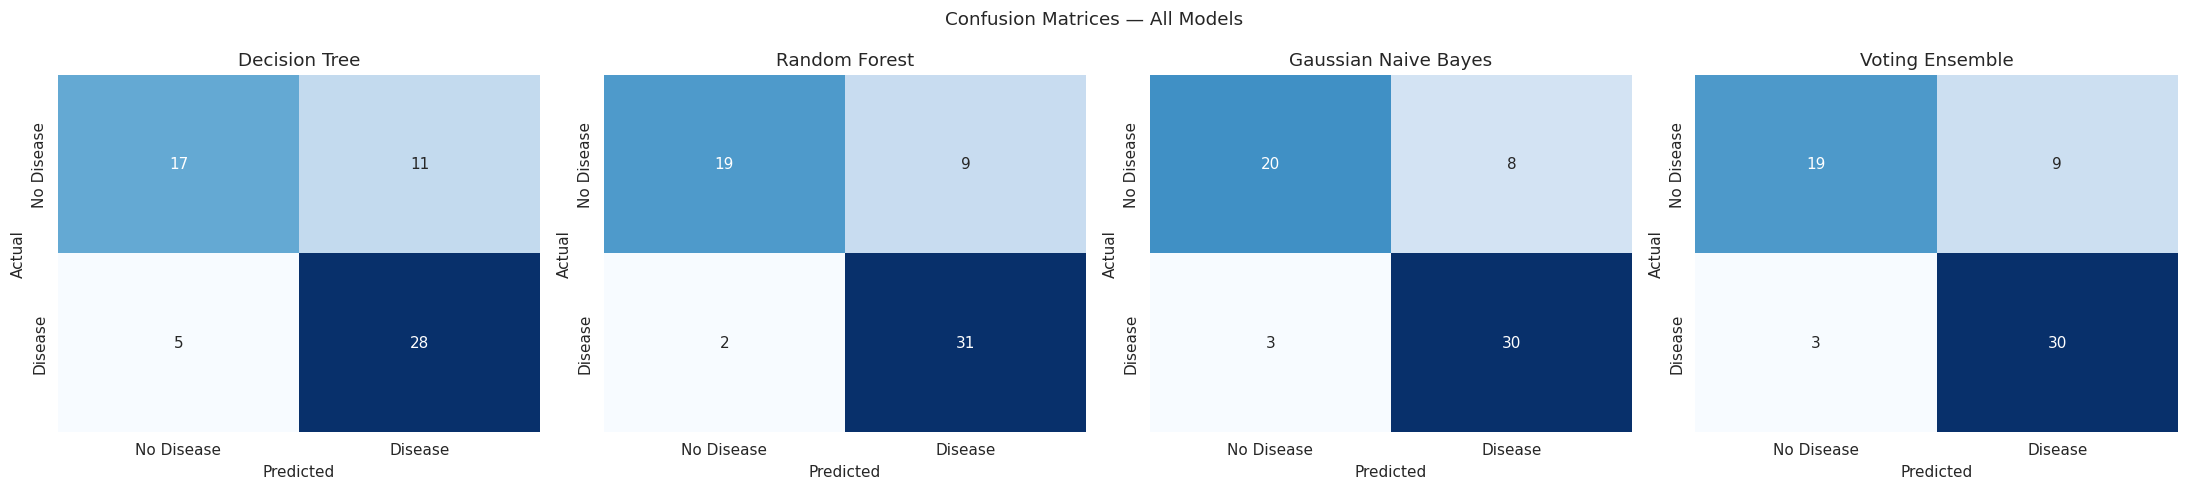

In [22]:
fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 4.5))
for ax, (name, (model, metrics, y_pred, y_proba)) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False,
                xticklabels=["No Disease", "Disease"], yticklabels=["No Disease", "Disease"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.suptitle("Confusion Matrices — All Models")
plt.tight_layout()
plt.show()


### 7.3 ROC curves

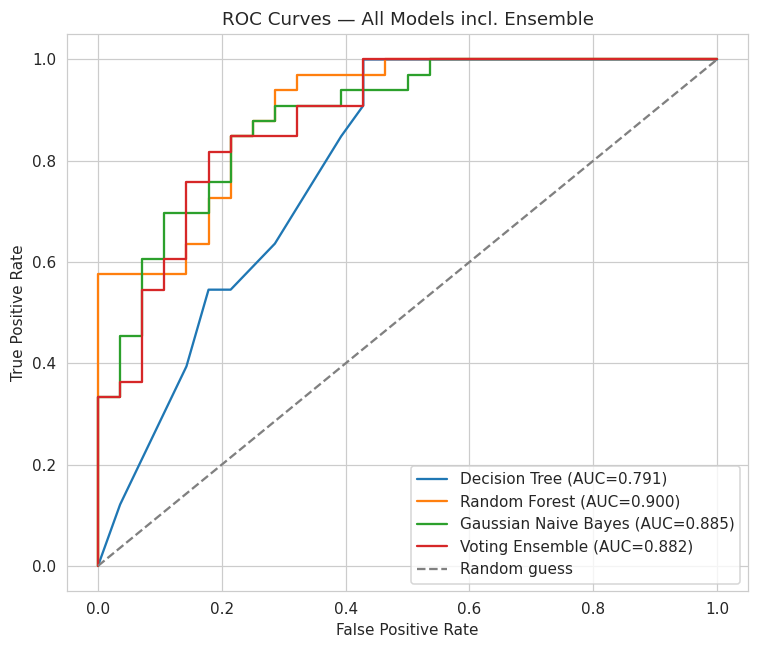

In [23]:
plt.figure(figsize=(7, 6))
for name, (model, metrics, y_pred, y_proba) in results.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = metrics["ROC-AUC"]
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Models incl. Ensemble")
plt.legend()
plt.tight_layout()
plt.show()


### 7.4 Full metrics comparison table & chart

,Accuracy,Precision,Recall (Sensitivity),F1,ROC-AUC,Brier Score
Decision Tree,0.738,0.718,0.848,0.778,0.791,0.181
Random Forest,0.820,0.775,0.939,0.849,0.900,0.132
Gaussian Naive Bayes,0.820,0.789,0.909,0.845,0.885,0.159
Voting Ensemble,0.803,0.769,0.909,0.833,0.882,0.139


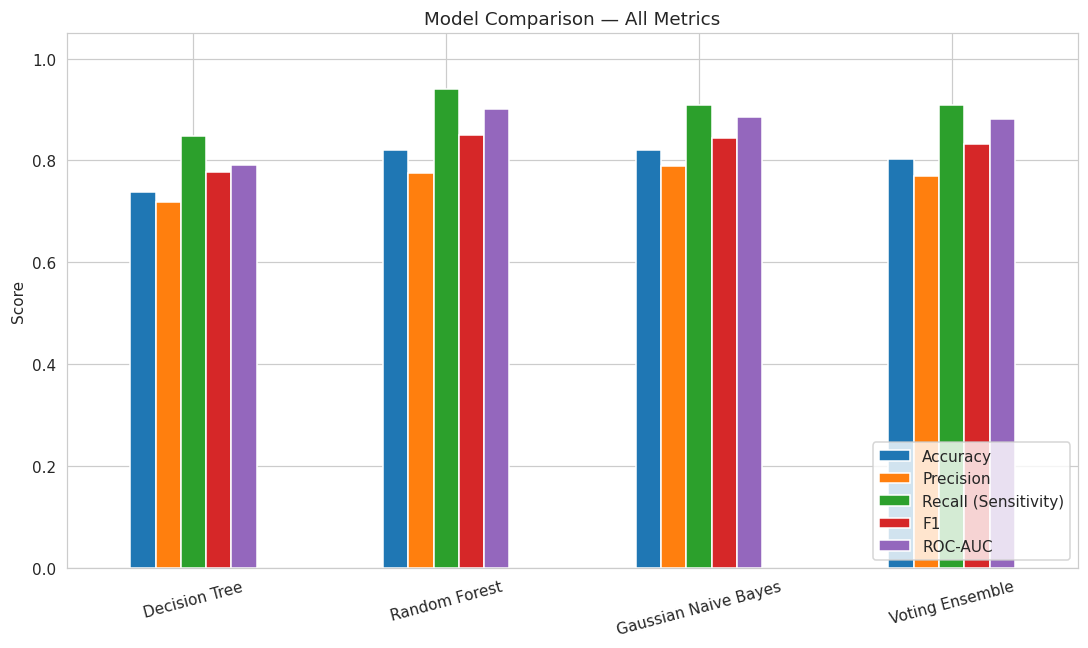

Saved -> reports/model_comparison_metrics.csv


In [24]:
metrics_df = pd.DataFrame(all_metrics).T
display(metrics_df.round(3))

metrics_df.drop(columns=["Brier Score"]).plot(kind="bar", figsize=(10, 6))
plt.title("Model Comparison — All Metrics")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.legend(loc="lower right")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

metrics_df.to_csv("../reports/model_comparison_metrics.csv")
print("Saved -> reports/model_comparison_metrics.csv")


## 8. Interpretability — Feature Importance & Decision Tree Rules

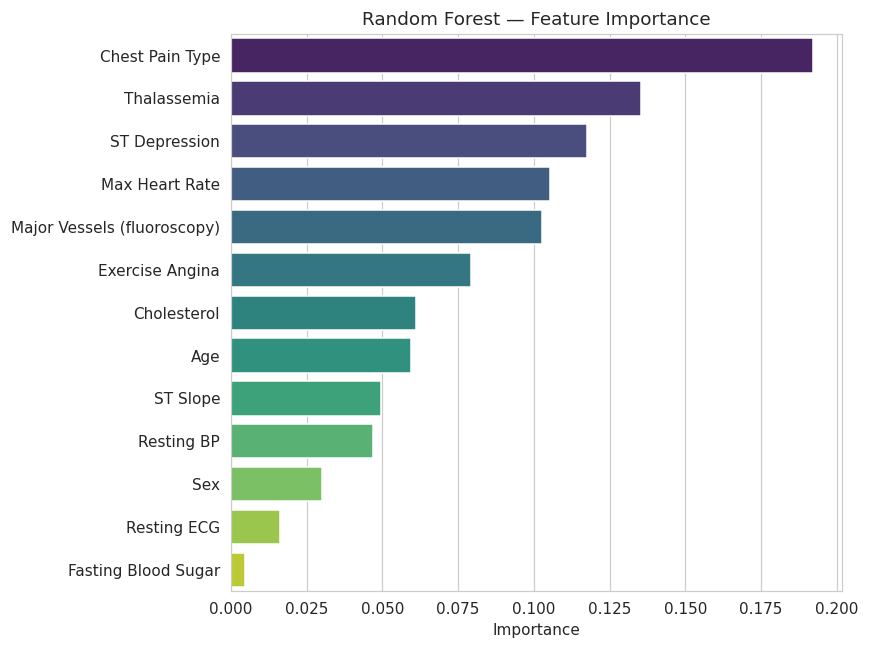

In [25]:
FEATURE_NAMES_READABLE = {
    "age": "Age", "sex": "Sex", "cp": "Chest Pain Type", "trestbps": "Resting BP",
    "chol": "Cholesterol", "fbs": "Fasting Blood Sugar", "restecg": "Resting ECG",
    "thalach": "Max Heart Rate", "exang": "Exercise Angina", "oldpeak": "ST Depression",
    "slope": "ST Slope", "ca": "Major Vessels (fluoroscopy)", "thal": "Thalassemia"
}

importances = rf.feature_importances_
idx = np.argsort(importances)[::-1]
plt.figure(figsize=(8, 6))
sns.barplot(x=importances[idx],
            y=[FEATURE_NAMES_READABLE.get(feature_names[i], feature_names[i]) for i in idx],
            hue=[feature_names[i] for i in idx], palette="viridis", legend=False)
plt.title("Random Forest — Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


In [26]:
tree_text = export_text(dt, feature_names=feature_names)
print(tree_text)

with open("../reports/decision_tree_rules.txt", "w") as f:
    f.write(tree_text)
print("\nSaved -> reports/decision_tree_rules.txt")


|--- cp <= -0.44
|   |--- oldpeak <= -0.31
|   |   |--- ca <= -0.23
|   |   |   |--- thal <= 0.26
|   |   |   |   |--- age <= 0.45
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- age >  0.45
|   |   |   |   |   |--- class: 0
|   |   |   |--- thal >  0.26
|   |   |   |   |--- class: 0
|   |   |--- ca >  -0.23
|   |   |   |--- thalach <= 0.43
|   |   |   |   |--- exang <= 0.34
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- exang >  0.34
|   |   |   |   |   |--- class: 0
|   |   |   |--- thalach >  0.43
|   |   |   |   |--- class: 0
|   |--- oldpeak >  -0.31
|   |   |--- thal <= 0.26
|   |   |   |--- ca <= -0.23
|   |   |   |   |--- oldpeak <= 0.40
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- oldpeak >  0.40
|   |   |   |   |   |--- class: 0
|   |   |   |--- ca >  -0.23
|   |   |   |   |--- chol <= 0.75
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- chol >  0.75
|   |   |   |   |   |--- class: 0
|   |   |--- thal >  0.26
|   |   |   |--- class: 0
|--- cp >

## 9. SHAP Explainability (Random Forest)

SHAP values show, per patient, how much each feature pushed the prediction up or down —
this is the "reasoning path" the clinician dashboard will display.


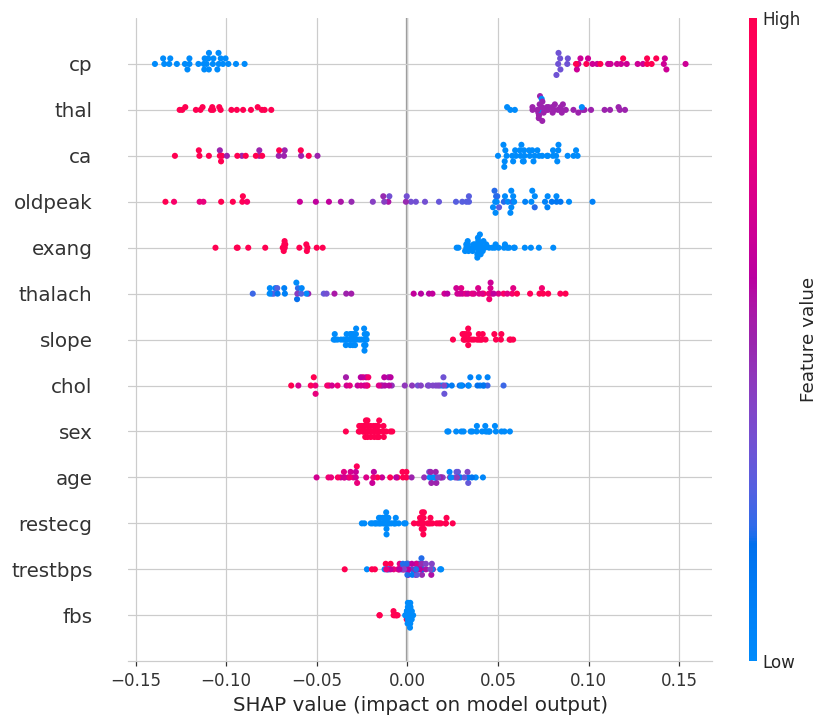

In [27]:
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test_scaled)

if isinstance(shap_values, list):
    sv_for_disease_class = shap_values[1]
else:
    sv_arr = np.asarray(shap_values)
    sv_for_disease_class = sv_arr[:, :, 1] if sv_arr.ndim == 3 else sv_arr

shap.summary_plot(sv_for_disease_class, X_test_scaled, feature_names=feature_names)


### 9.1 Explain a single patient's prediction (plain language)

In [28]:
def explain_single_patient(explainer, patient_row_df, feature_names, top_n=5):
    shap_values = explainer.shap_values(patient_row_df)
    if isinstance(shap_values, list):
        sv = np.asarray(shap_values[1])[0]
    else:
        sv = np.asarray(shap_values)
        sv = sv[0, :, 1] if sv.ndim == 3 else sv[0]
    sv = np.ravel(sv)
    contributions = list(zip(feature_names, sv))
    contributions.sort(key=lambda x: abs(x[1]), reverse=True)
    return contributions[:top_n]

sample_patient = X_test_scaled.iloc[[0]]
top_factors = explain_single_patient(explainer, sample_patient, feature_names)

actual_label = "Disease" if y_test.iloc[0] == 1 else "No Disease"
pred_proba = ensemble.predict_proba(sample_patient)[0][1]

print(f"Actual diagnosis: {actual_label}")
print(f"Ensemble predicted disease probability: {pred_proba:.1%}\n")
print("Top contributing factors:")
for feat, val in top_factors:
    direction = "increases" if val > 0 else "decreases"
    readable = FEATURE_NAMES_READABLE.get(feat, feat)
    print(f"  - {readable} {direction} risk (impact: {val:+.3f})")


Actual diagnosis: No Disease
Ensemble predicted disease probability: 12.1%

Top contributing factors:
  - Chest Pain Type decreases risk (impact: -0.107)
  - Major Vessels (fluoroscopy) decreases risk (impact: -0.082)
  - Exercise Angina decreases risk (impact: -0.078)
  - Max Heart Rate decreases risk (impact: -0.068)
  - ST Depression increases risk (impact: +0.058)


## 10. Save Models & Artifacts (for the Streamlit dashboard)

In [29]:
import os
os.makedirs("models", exist_ok=True)

joblib.dump(dt, "../models/decision_tree.pkl")
joblib.dump(rf, "../models/random_forest.pkl")
joblib.dump(nb, "../models/gaussian_nb.pkl")
joblib.dump(ensemble, "../models/voting_ensemble.pkl")
joblib.dump(scaler, "../models/scaler.pkl")
joblib.dump(explainer, "../models/shap_explainer.pkl")

with open("../models/feature_names.json", "w") as f:
    json.dump(feature_names, f)

print("All models + scaler + SHAP explainer + feature list saved to models/")


All models + scaler + SHAP explainer + feature list saved to models/


## 11. Summary

- Random Forest had the best individual AUC and best calibration (lowest Brier score).
- The soft-voting ensemble stays close to the best individual model while blending all three
  perspectives, and is what powers the dashboard's confidence score.
- Recall was prioritized throughout given the medical screening context — missing a sick
  patient is costlier than a false alarm.
- Top predictors (via SHAP + RF feature importance): chest pain type, thalassemia, number of
  major vessels, ST depression, and max heart rate — consistent with cardiology literature.

**Next step:** run `streamlit run app/dashboard.py` to interact with these trained models
through the clinician-facing dashboard.
